In [1]:
import numpy as np
import torch

from rlaopt.solvers import PCGConfig, SAPConfig, SAPAccelConfig
from rlaopt.preconditioners import NystromConfig, NewtonConfig
from rlaopt.kernels import KernelConfig

from scalable_gp_inference.kernel_linsys import KernelLinSys

In [2]:
seed = 0
ntr = 1000
ntst = 200
d=10

In [3]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(seed)

In [4]:
device = torch.device("cuda:0")

Xtr = torch.randn(ntr, d,device=device)
Xtst = torch.randn(ntst,d,device=device)

b = Xtr @ torch.randn((d,1),device=device) / (d)**(0.5) + 0.001 * torch.randn((ntr,1),device=device)

kernel_type = "rbf"
distributed = False
devices = set([torch.device("cuda:0")])
num_posterior_samples = 64
num_random_features = 2048

kernel_config = KernelConfig(const_scaling=1.0,lengthscale=5.0)

In [5]:
Ksys = KernelLinSys(
    Xtr, 
    b, 
    0.01,
    kernel_type="rbf", 
    kernel_config=kernel_config, 
    use_full_kernel=True,
    devices=devices
)

In [6]:
K = Ksys.A
Kmat = K @ torch.eye(ntr,device=device)

In [7]:
wStar = torch.linalg.solve(Kmat + 0.01 * torch.eye(ntr,device=device), b)

In [8]:
V, lambd, _ = torch.linalg.svd(Kmat)

In [9]:
ranks = [1, 10, 100, 1000]

In [10]:
# w_list = []

In [11]:
def _evaluate_subspace_convergence(w, Ksys, V, wStar, ranks):
    results = {}
    d = w - wStar
    for r in ranks:
        Vr = V[:,0:r]
        dr = Vr.T @ d
        Kr = Vr.T @ (Ksys.A @ Vr)
        results[f"subspace_{r}"] = dr.T @ (Kr @ dr)
    return results

def _compute_tail_average(w_list):
    num_iters = len(w_list)

    print(f"Computing tail average over last {num_iters // 2} iterates.")

    tail_start = num_iters // 2
    tail_w_list = w_list[tail_start:num_iters]
    tail_avg = torch.mean(torch.stack(tail_w_list), dim=0)
    return tail_avg

def callback_fn(w, Ksys, V):
    w_list.append(w.clone())
    tail_avg = _compute_tail_average(w_list)

    results_non_averaged = _evaluate_subspace_convergence(w, Ksys, V, wStar, ranks)
    results_averaged = _evaluate_subspace_convergence(tail_avg, Ksys, V, wStar, ranks)

    results = {}
    for key in results_non_averaged:
        results[key] = {
            "non_averaged": results_non_averaged[key].item(),
            "averaged": results_averaged[key].item(),
        }

    return results

In [12]:
# blk_sz = Xtr.shape[0] // 100

# max_iters = 40 * Xtr.shape[0] // blk_sz

# solver_config = SAPConfig(
#     precond_config=NewtonConfig(rho=0.01),
#     max_iters=max_iters,
#     atol=1e-10,
#     rtol=1e-10,
#     blk_sz=blk_sz,
#     accel=False,
#     accel_config=None,
#     device=torch.device("cuda:0"),
# )


In [13]:
# wStar, log = Ksys.solve(solver_config, torch.zeros_like(b), callback_fn=callback_fn, callback_args=[V])

In [14]:
# subspace_errs = {}
# for i in log:
#     for key, value in log[i]["metrics"]["callback"].items():
#         if key not in subspace_errs:
#             subspace_errs[key] = []
#         subspace_errs[key].append(value)

In [15]:
# print(subspace_errs)

In [16]:
import matplotlib.pyplot as plt

In [17]:
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})

In [18]:
# # Set font size to match other figures (FONTSIZE = 20)
# plt.rcParams.update({"font.size": 20})

# # Use consistent figure size from plotting constants (SZ_COL=8, SZ_ROW=6)
# plt.figure(figsize=(10, 6))

# # Define colors for each rank to ensure consistency
# colors = plt.cm.tab10(np.linspace(0, 1, len(subspace_errs)))
# color_map = {key: colors[i] for i, key in enumerate(subspace_errs.keys())}

# for key, value in subspace_errs.items():
#     # Extract non-averaged and averaged values
#     non_averaged = [v["non_averaged"] for v in value]
#     averaged = [v["averaged"] for v in value]
    
#     # Plot non-averaged with solid line using consistent color
#     plt.semilogy(non_averaged, label=f"{key} (non-averaged)", linestyle='-', color=color_map[key])
    
#     # Plot averaged with dashed line using same color
#     plt.semilogy(averaged, label=f"{key} (tail averaged)", linestyle='--', color=color_map[key])

# plt.xlabel('Iteration')
# plt.ylabel('Subspace Error')
# plt.title('Subspace Convergence: Non-averaged vs Tail Averaged')

# # Position legend below the figure with more spacing to avoid overlap
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
# plt.tight_layout()
# plt.show()

In [19]:
def run_subspace_convergence_experiment(block_sizes, grid_shape, figsize=(12, 8)):
    """
    Run subspace convergence experiment over varying block sizes.
    
    Args:
        block_sizes: List of block sizes to test
        grid_shape: Tuple (nrows, ncols) for subplot grid
        figsize: Figure size tuple
    
    Returns:
        Dictionary with results for each block size
    """
    # Set font size to match other figures
    plt.rcParams.update({"font.size": 20})
    
    # Create subplot grid
    fig, axes = plt.subplots(grid_shape[0], grid_shape[1], figsize=figsize)
    if grid_shape[0] * grid_shape[1] == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Store all results
    all_results = {}
    
    # Define colors for each rank to ensure consistency across plots
    colors = plt.cm.tab10(np.linspace(0, 1, len(ranks)))
    color_map = {f"subspace_{r}": colors[i] for i, r in enumerate(ranks)}
    
    for idx, blk_sz in enumerate(block_sizes):
        if idx >= len(axes):
            print(f"Warning: More block sizes than subplots. Skipping block size {blk_sz}")
            break
            
        print(f"Running experiment with block size: {blk_sz}")
        
        # Reset solver state
        global w_list
        w_list = []
        
        # Configure solver with current block size
        max_iters = 40 * Xtr.shape[0] // blk_sz
        solver_config = SAPConfig(
            precond_config=NewtonConfig(rho=0.01),
            max_iters=max_iters,
            atol=1e-10,
            rtol=1e-10,
            blk_sz=blk_sz,
            accel=False,
            accel_config=None,
            device=torch.device("cuda:0"),
        )
        
        # Run solver
        _, log = Ksys.solve(solver_config, torch.zeros_like(b), 
                                   callback_fn=callback_fn, callback_args=[V])
        
        # Process results
        subspace_errs = {}
        for i in log:
            for key, value in log[i]["metrics"]["callback"].items():
                if key not in subspace_errs:
                    subspace_errs[key] = []
                subspace_errs[key].append(value)
        
        all_results[f"blk_sz_{blk_sz}"] = subspace_errs
        
        # Plot results on current subplot
        ax = axes[idx]
        
        for key, value in subspace_errs.items():
            # Extract non-averaged and averaged values
            non_averaged = [v["non_averaged"] for v in value]
            averaged = [v["averaged"] for v in value]
            
            # Extract rank from key (e.g., "subspace_1" -> "1")
            rank = key.split('_')[1]
            
            # Plot non-averaged with solid line using consistent color
            ax.semilogy(non_averaged, label=f"$\\ell = {rank}$ (non-averaged)", 
                       linestyle='-', color=color_map[key])
            
            # Plot averaged with dashed line using same color
            ax.semilogy(averaged, label=f"$\\ell = {rank}$ (tail averaged)", 
                       linestyle='--', color=color_map[key])
        
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Subspace Error')
        ax.set_title(f'$b = {blk_sz}$')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(block_sizes), len(axes)):
        axes[idx].set_visible(False)
    
    # Add single legend below all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), 
               ncol=3, frameon=False)
    
    plt.tight_layout()
    plt.show()
    
    return all_results

Running experiment with block size: 10
Computing tail average over last 0 iterates.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
Computing tail average over last 1 iterates.
[pyKeOps] Warning : at least on

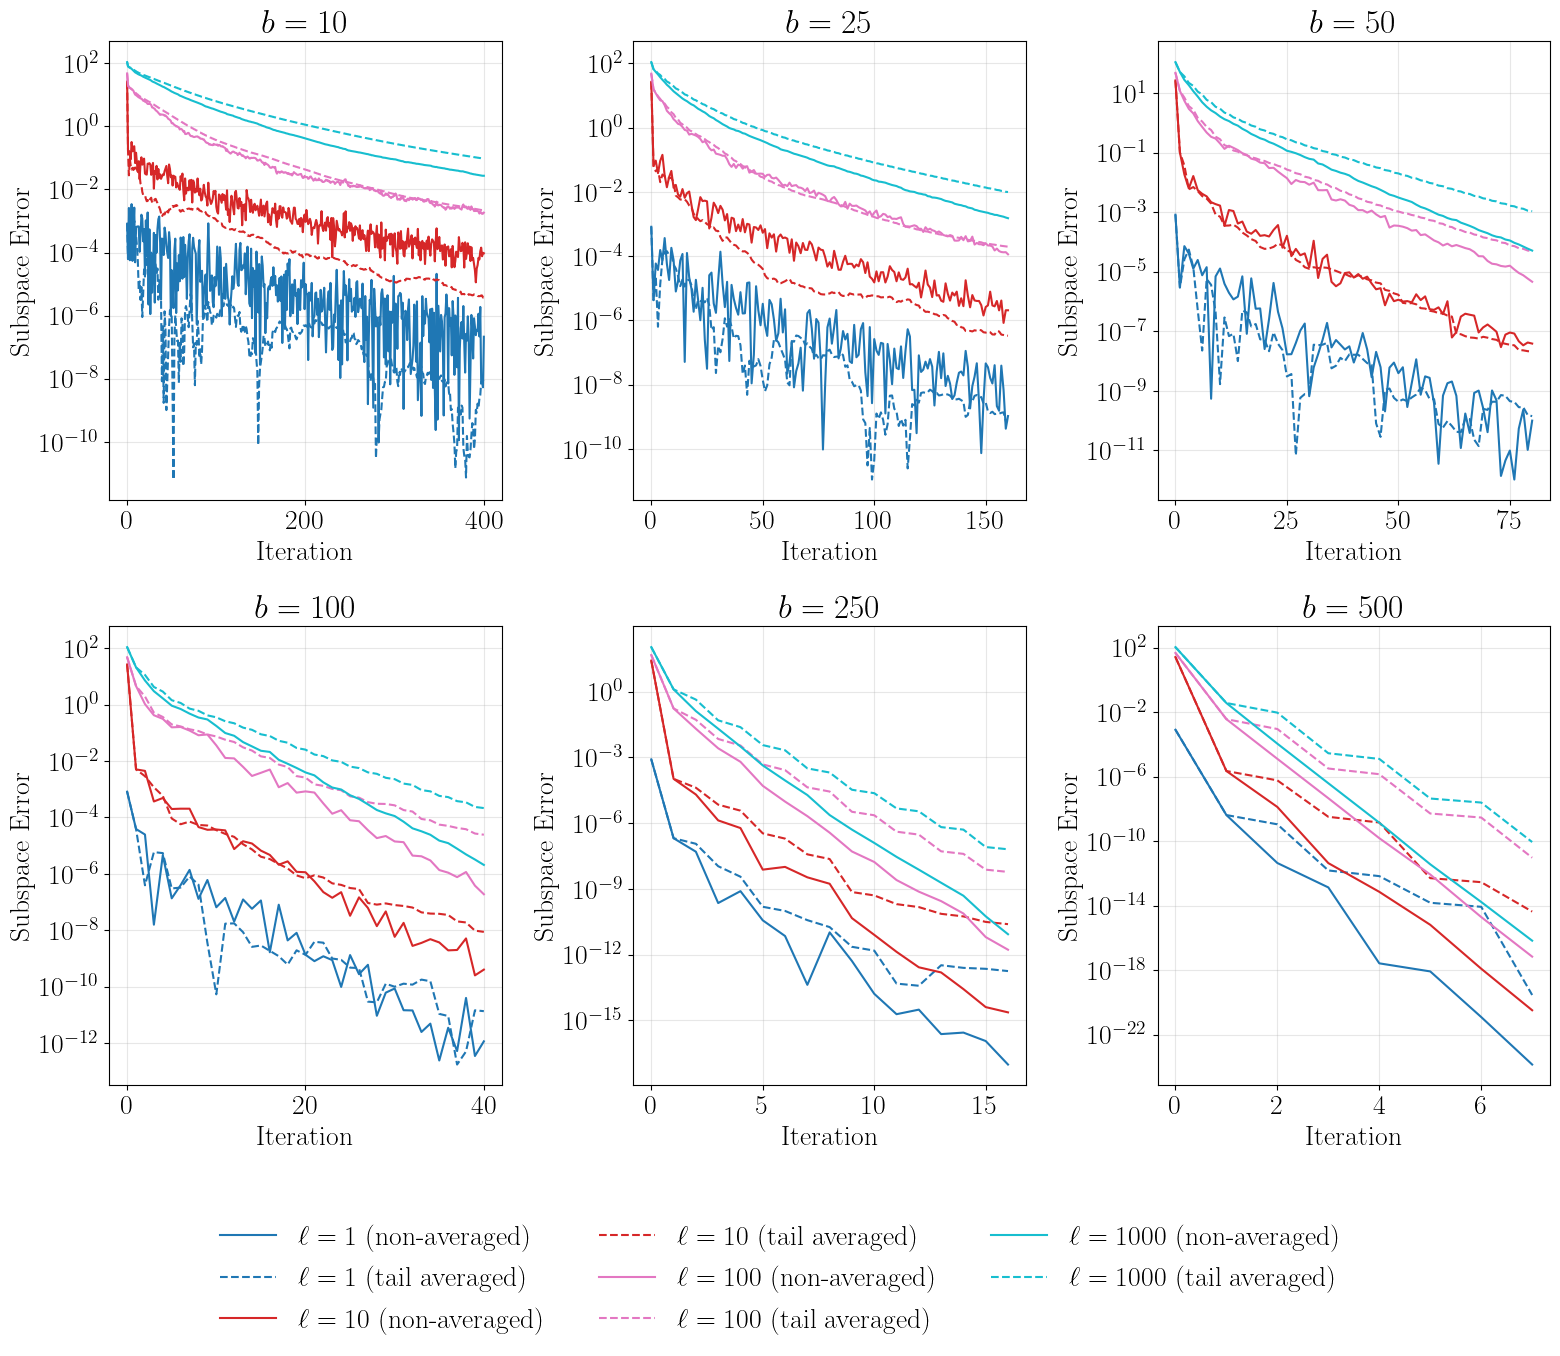

In [20]:
# Example usage: Test different block sizes
block_sizes_to_test = [10, 25, 50, 100, 250, 500]

# Run experiment with 2x2 grid
results = run_subspace_convergence_experiment(
    block_sizes=block_sizes_to_test,
    grid_shape=(2, 3),
    figsize=(16, 12)
)

In [21]:
# Analyze results: Print convergence summary for each block size
print("Convergence Summary:")
print("=" * 50)

for blk_key, blk_results in results.items():
    print(f"\n{blk_key}:")
    for subspace_key, values in blk_results.items():
        final_non_avg = values[-1]["non_averaged"]
        final_avg = values[-1]["averaged"]
        print(f"  {subspace_key}:")
        print(f"    Final non-averaged error: {final_non_avg:.2e}")
        print(f"    Final tail-averaged error: {final_avg:.2e}")
        print(f"    Improvement ratio: {final_non_avg/final_avg:.2f}x")

Convergence Summary:

blk_sz_10:
  subspace_1:
    Final non-averaged error: 2.14e-07
    Final tail-averaged error: 9.42e-09
    Improvement ratio: 22.75x
  subspace_10:
    Final non-averaged error: 9.48e-05
    Final tail-averaged error: 3.74e-06
    Improvement ratio: 25.35x
  subspace_100:
    Final non-averaged error: 1.84e-03
    Final tail-averaged error: 2.16e-03
    Improvement ratio: 0.85x
  subspace_1000:
    Final non-averaged error: 2.71e-02
    Final tail-averaged error: 9.49e-02
    Improvement ratio: 0.29x

blk_sz_25:
  subspace_1:
    Final non-averaged error: 1.06e-09
    Final tail-averaged error: 7.41e-10
    Improvement ratio: 1.43x
  subspace_10:
    Final non-averaged error: 2.06e-06
    Final tail-averaged error: 3.34e-07
    Improvement ratio: 6.18x
  subspace_100:
    Final non-averaged error: 1.14e-04
    Final tail-averaged error: 1.97e-04
    Improvement ratio: 0.58x
  subspace_1000:
    Final non-averaged error: 1.51e-03
    Final tail-averaged error: 9.8